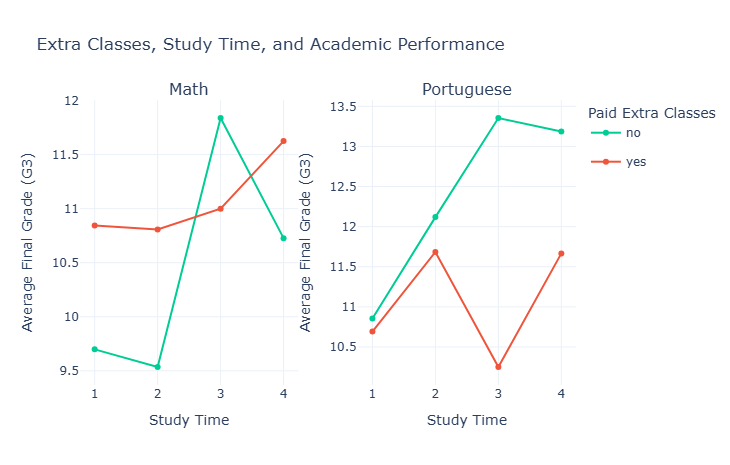

In [2]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load Dataset 3
df3_mat = pd.read_csv("student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("student-por.csv", sep=None, engine="python")

# Combine Math + Portuguese
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

# Group by subject, studytime, and paid extra classes
summary = (
    df3.groupby(["Subject", "studytime", "paid"], observed=False)["G3"]
    .mean()
    .reset_index()
)

# Fixed colors for paid status
color_map = {
    "no": "#00CC96",
    "yes": "#EF553B"
}

# Create subplot: Math + Portuguese
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Math", "Portuguese"],
    horizontal_spacing=0.12
)

for col, subject in enumerate(["Math", "Portuguese"], start=1):
    temp_subject = summary[summary["Subject"] == subject]
    
    for paid_status in ["no", "yes"]:
        temp = temp_subject[temp_subject["paid"] == paid_status]
        
        fig.add_trace(
            go.Scatter(
                x=temp["studytime"],
                y=temp["G3"],
                mode="lines+markers",
                name=paid_status,
                legendgroup=paid_status,
                showlegend=True if col == 1 else False,
                line=dict(color=color_map[paid_status]),
                marker=dict(color=color_map[paid_status])
            ),
            row=1,
            col=col
        )

fig.update_layout(
    title_text="Extra Classes, Study Time, and Academic Performance",
    height=450,
    width=1000,
    template="plotly_white",
    legend_title_text="Paid Extra Classes"
)

fig.update_xaxes(
    title_text="Study Time",
    tickmode="array",
    tickvals=[1, 2, 3, 4]
)

fig.update_yaxes(title_text="Average Final Grade (G3)")

fig.show()